# Cast Defect Classification — Experiments

Companion notebook for the Word report. Run top to bottom after `split_dataset` → `train` → `evaluate`. Screenshots for deployment and feature maps: capture from Streamlit (`streamlit run app/streamlit_app.py`).

In [18]:
%matplotlib inline
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.utils import load_config, get_device, set_seed, resolve_path
from src.dataset import get_dataloaders
from src.train_engine import Trainer
from src.evaluate import evaluate_model, collect_predictions
from src.inference import load_model_for_inference, predict_image
from src.visualization import save_all_training_plots, save_confusion_matrix_plot
import json

config = load_config(ROOT / "configs/config.yaml")
set_seed(config["random_seed"])
device = get_device(config)
print("Device:", device)

Device: mps


## 1. Dataset overview

Binary labels from `data/label.csv`, images in `data/raw_images/`.

In [19]:
import csv
from collections import Counter

labels_path = ROOT / 'data/label.csv'
counts = Counter()
with labels_path.open(newline='', encoding='utf-8') as f:
    for row in csv.DictReader(f):
        counts[row['choice'].strip().lower()] += 1
total = sum(counts.values())
print('Total labeled images:', total)
for name, n in sorted(counts.items()):
    print(f'  {name}: {n} ({100 * n / total:.1f}%)')

Total labeled images: 7285
  defect: 3836 (52.7%)
  normal: 3449 (47.3%)


## 2. Data preprocessing

- Resize **224×224**, ImageNet normalization
- Stratified split **80% / 10% / 10%** (`scripts/split_dataset.py`, seed 42)
- Train augmentations: horizontal flip, rotation ±10°

## 3. Custom CNN architecture

Three convolutional blocks (32 → 64 → 96 channels), BatchNorm, MaxPool, dropout classifier. See `src/model.py`.

In [20]:
from src.model import build_model

model_cnn = build_model(config, num_classes=2)
n_params = sum(p.numel() for p in model_cnn.parameters())
print(model_cnn)
print(f'Parameters: {n_params:,}')

CastDefectCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): AdaptiveAvgPool2d(output_size=(4, 4))
  )
  (classifier): Sequential(
    (0): Flatten(

## 4. Load data

In [21]:
train_loader, val_loader, test_loader, class_names = get_dataloaders(config, device)
print("Classes:", class_names)
print("Train:", len(train_loader.dataset), "Val:", len(val_loader.dataset), "Test:", len(test_loader.dataset))

Classes: ['defect', 'normal']
Train: 5827 Val: 727 Test: 731


## 5. Training

Set `RUN_TRAINING = False` if you already ran `python scripts/train.py`.

In [22]:
RUN_TRAINING = False

if RUN_TRAINING:
    trainer = Trainer(config, train_loader, val_loader, class_names, device)
    history = trainer.train()
    save_all_training_plots(history, config)
else:
    hist_path = resolve_path(config["evaluation"]["metrics_file"]).parent / "training_history.json"
    history = json.load(open(hist_path)) if hist_path.exists() else {}
    print("Loaded history:", bool(history))

Loaded history: True


## 6. Evaluation and training plots

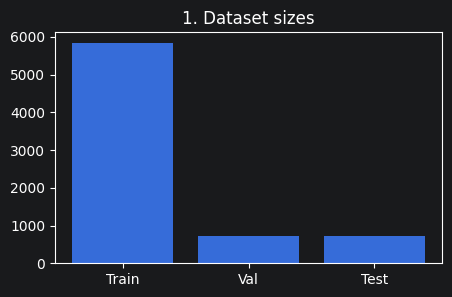

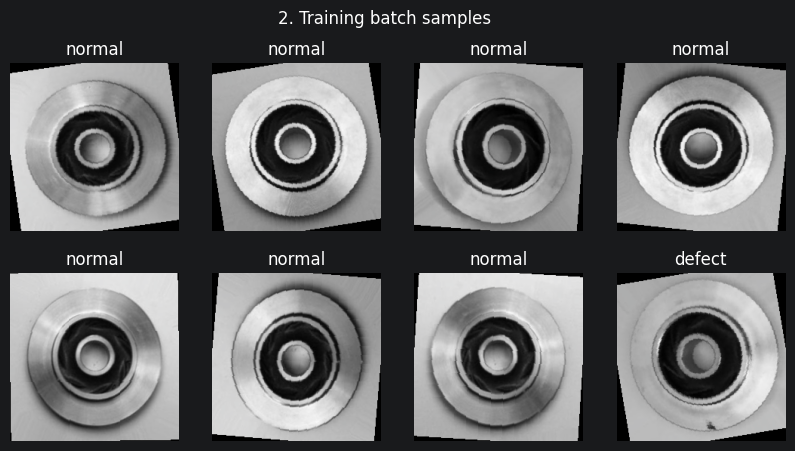

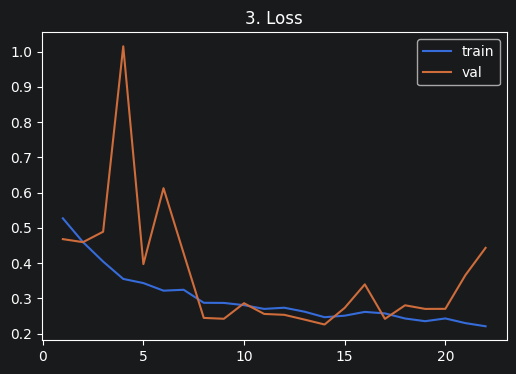

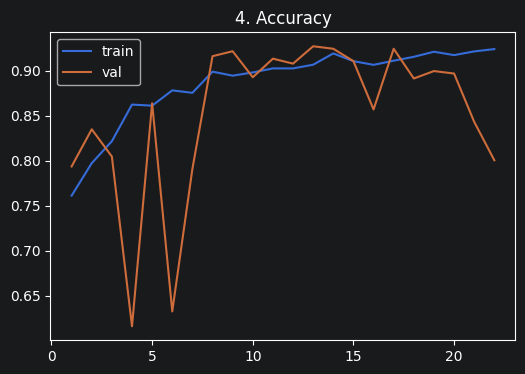

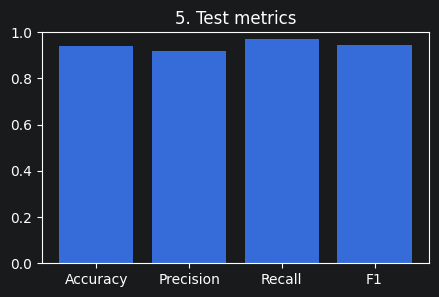

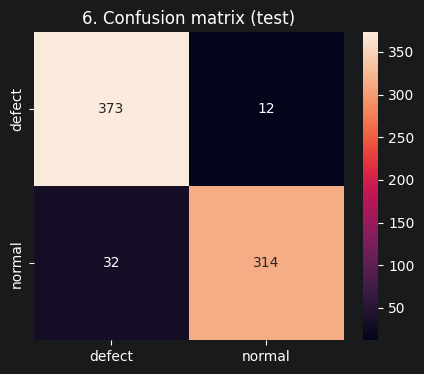

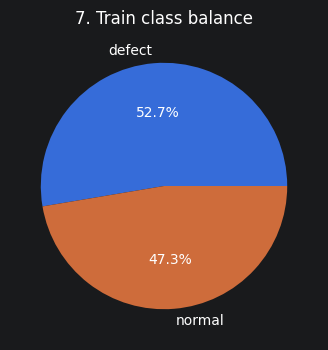

In [23]:
MEAN = np.array([0.485, 0.456, 0.406])
STD = np.array([0.229, 0.224, 0.225])

def show_img(tensor):
    img = tensor.cpu().numpy().transpose(1, 2, 0) * STD + MEAN
    return np.clip(img, 0, 1)

# 1. Dataset sizes
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(["Train", "Val", "Test"], [len(train_loader.dataset), len(val_loader.dataset), len(test_loader.dataset)])
ax.set_title("1. Dataset sizes")
plt.show()

# 2. Sample images
imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, img, lbl in zip(axes.flat, imgs[:8], labels[:8]):
    ax.imshow(show_img(img))
    ax.set_title(class_names[lbl])
    ax.axis("off")
fig.suptitle("2. Training batch samples")
plt.show()

# 3-4. Loss and accuracy curves
if history.get("train_loss"):
    ep = range(1, len(history["train_loss"]) + 1)
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(ep, history["train_loss"], label="train")
    ax.plot(ep, history["val_loss"], label="val")
    ax.set_title("3. Loss")
    ax.legend()
    plt.show()

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(ep, history["train_accuracy"], label="train")
    ax.plot(ep, history["val_accuracy"], label="val")
    ax.set_title("4. Accuracy")
    ax.legend()
    plt.show()
else:
    print("No history — run scripts/train.py first")

# 5-6. Evaluation + confusion matrix
model, class_names, device = load_model_for_inference(config, device=device)
metrics, y_true, y_pred = evaluate_model(model, test_loader, device, class_names, config)

fig, ax = plt.subplots(figsize=(5, 3))
names = ["Accuracy", "Precision", "Recall", "F1"]
vals = [metrics["accuracy"], metrics["precision"], metrics["recall"], metrics["f1_score"]]
ax.bar(names, vals)
ax.set_ylim(0, 1)
ax.set_title("5. Test metrics")
plt.show()

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", ax=ax, xticklabels=class_names, yticklabels=class_names)
ax.set_title("6. Confusion matrix (test)")
plt.show()

# 7. Class distribution in train
counts = np.bincount(train_loader.dataset.targets, minlength=len(class_names))
fig, ax = plt.subplots(figsize=(4, 4))
ax.pie(counts, labels=class_names, autopct="%1.1f%%")
ax.set_title("7. Train class balance")
plt.show()

## 7. Hyperparameter tuning (learning rate)

Two runs: **A** lr=0.001, **B** lr=0.0005. Generate with `python scripts/run_hyperparameter_tuning.py`.

,experiment,learning_rate,batch_size,dropout,accuracy,precision,recall,f1_score,training_time_seconds,epochs_trained
0,A,0.0010,16,0.4,0.926129,0.893112,0.976623,0.933002,NaN,22
1,B,0.0005,16,0.4,0.934337,0.918114,0.961039,0.939086,420.02,12


Best: experiment B (lr=0.0005, F1=0.9391)


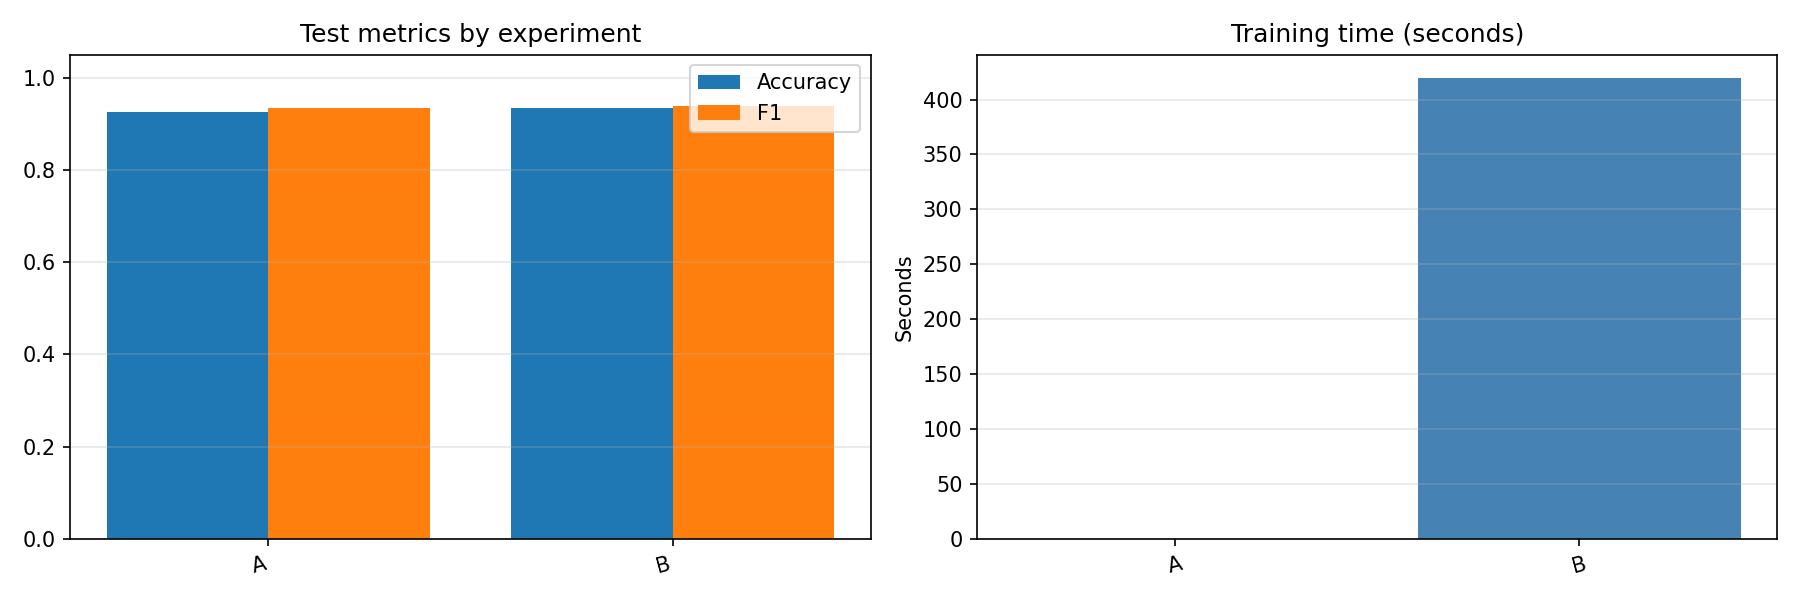

In [24]:
import pandas as pd
from IPython.display import Image, display

tuning_csv = ROOT / 'outputs/tuning/tuning_results.csv'
if tuning_csv.exists():
    df = pd.read_csv(tuning_csv)
    display(df)
    best = df.loc[df['f1_score'].idxmax()]
    print(f"Best: experiment {best['experiment']} (lr={best['learning_rate']}, F1={best['f1_score']:.4f})")
    img = ROOT / 'outputs/tuning/tuning_comparison.png'
    if img.exists():
        display(Image(filename=str(img), width=700))
else:
    print('Run: python scripts/run_hyperparameter_tuning.py')

## 8. Baseline comparison (ResNet18)

Transfer-learning baseline on the same splits. Generate with `python scripts/train_baseline.py` (after `evaluate.py`).

,Model,Accuracy,Precision,Recall,F1
0,Custom CNN,0.9261,0.8931,0.9766,0.933
1,ResNet18,0.9480,0.9263,0.9792,0.952


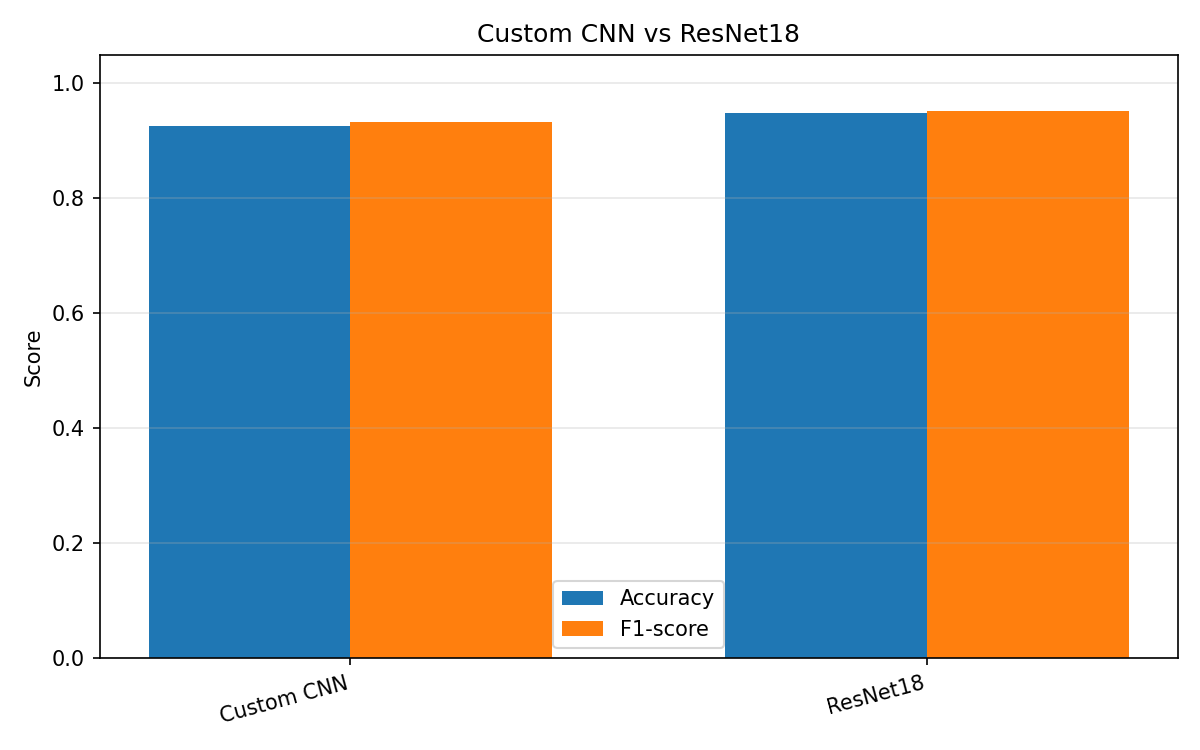

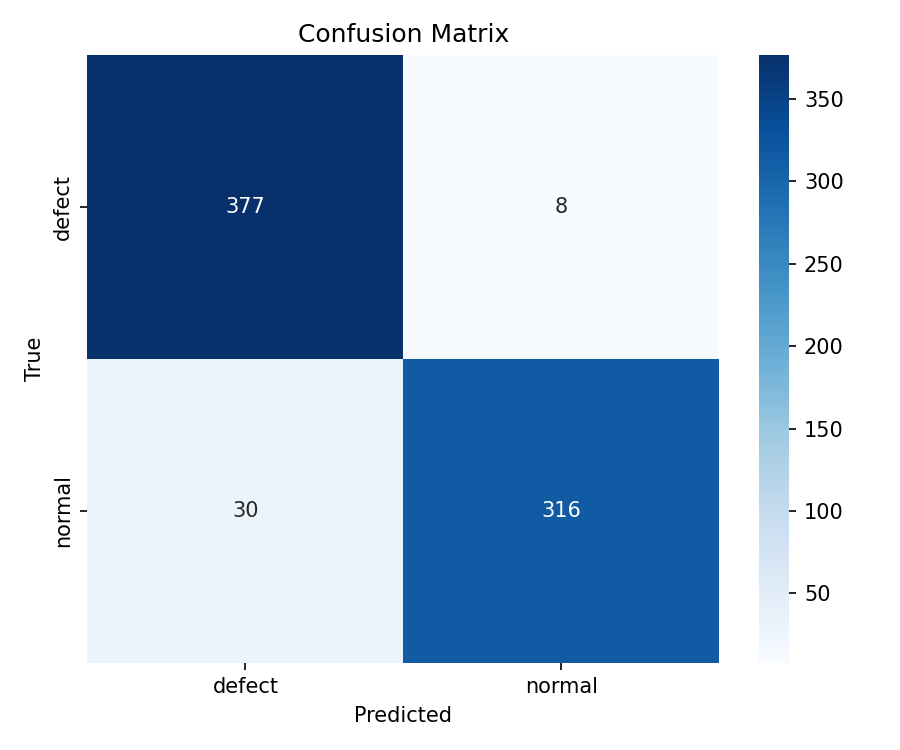

In [25]:
import pandas as pd
from IPython.display import Image, display

cmp = ROOT / 'outputs/baseline/model_comparison.csv'
if cmp.exists():
    display(pd.read_csv(cmp))
    for name in ('model_comparison.png', 'resnet18_confusion_matrix.png'):
        p = ROOT / 'outputs/baseline' / name
        if p.exists():
            display(Image(filename=str(p), width=480))
else:
    print('Run: python scripts/train_baseline.py')

## 9. Feature map analysis

Interactive maps: **Streamlit → Feature maps** tab (recommended for Word screenshots).

Optional: generate maps below from one defect and one normal image (requires `data/raw_images/`).

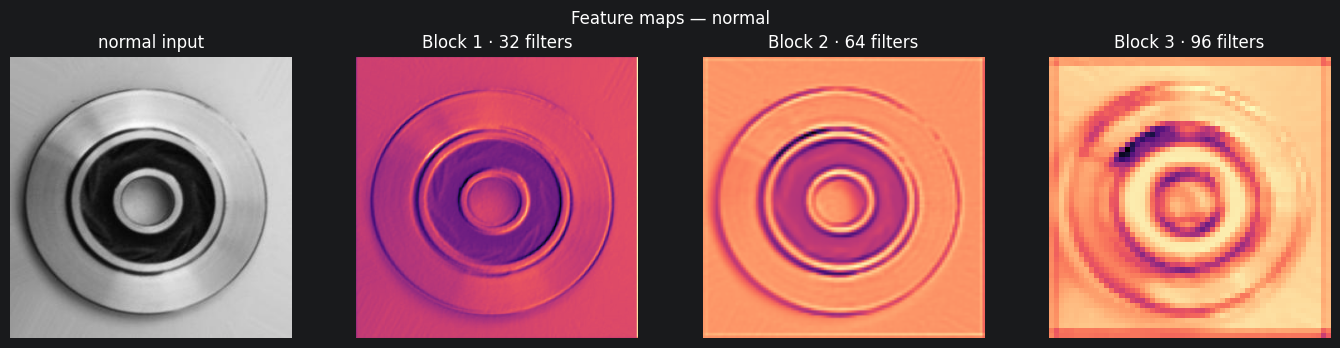

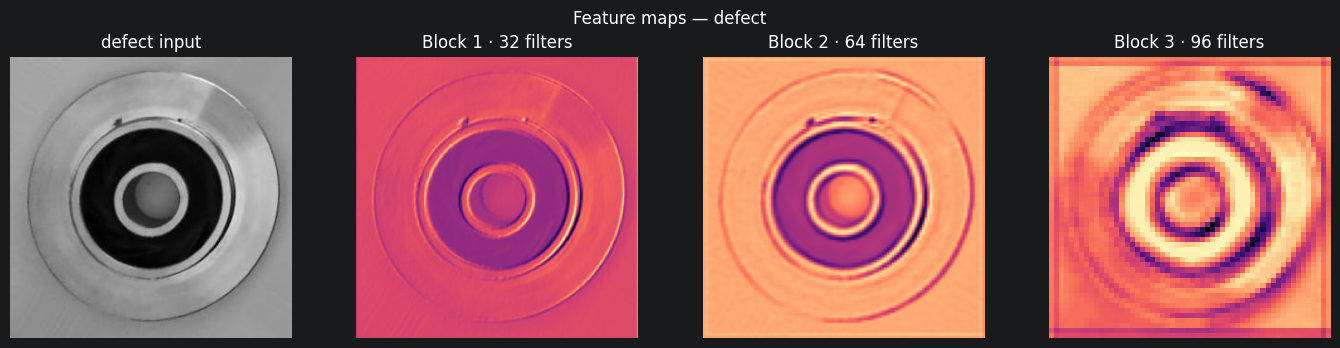

In [26]:
import csv
from PIL import Image
from IPython.display import display
import matplotlib.pyplot as plt

from src.explain import CONV_BLOCKS, extract_feature_map, image_to_tensor


def _sample_path(label: str):
    labels_file = ROOT / 'data/label.csv'
    raw = ROOT / 'data/raw_images'
    with labels_file.open(newline='', encoding='utf-8') as f:
        for row in csv.DictReader(f):
            if row.get('choice', '').strip().lower() == label:
                p = raw / row['image'].strip()
                if p.is_file():
                    return p
    return None


model_fm, class_names_fm, device_fm = load_model_for_inference(config, device=device)
model_fm.eval()

for label in ('normal', 'defect'):
    path = _sample_path(label)
    if not path:
        print('Missing sample for', label)
        continue
    img = Image.open(path).convert('RGB')
    tensor = image_to_tensor(img, config, device_fm)
    fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
    axes[0].imshow(img)
    axes[0].set_title(f'{label} input')
    axes[0].axis('off')
    for ax, (block, (_, title)) in zip(axes[1:], CONV_BLOCKS.items()):
        fmap = extract_feature_map(model_fm, tensor, block)
        ax.imshow(fmap, cmap='magma')
        ax.set_title(title)
        ax.axis('off')
    fig.suptitle(f'Feature maps — {label}', fontsize=12)
    plt.tight_layout()
    plt.show()